<a href="https://colab.research.google.com/github/akash-g0807/Numerical-Analysis/blob/main/6_Optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import plotly.graph_objects as go

f = lambda x: -np.exp(-x**2) - np.sin(x**2)
x = np.linspace(0,1.5,1000)
y = f(x)
print(x[np.argmin(y)])

1.1366366366366367


In [ ]:
def golden_section(f, a, b, c, tol=1e-12):

    assert a < c < b, "Need a < c < b"
    assert f(c) < f(a) and f(c) < f(b), "Need f(c) < f(a) and f(c) < f(b)"

    while b - a >= tol:
        # Choose a new point in the larger subinterval
        if (c - a) > (b - c):
            d = 0.5 * (a + c)
        else:
            d = 0.5 * (c + b)

        if f(d) < f(c):
            if d < c:
                b = c
                c = d
            else:
                a = c
                c = d
        else:
            if d < c:
                a = d
            else:
                b = d

        # debugging:
        # print(a, c, b)

    return c

In [ ]:
def f(x):
    return -math.exp(-x**2) - math.sin(x**2)

xmin = golden_section(f, 0.8, 1.6, 1.2)
print("xmin =", xmin)
print("f(xmin) =", f(xmin))

xmin = 1.1369677752256389
f(xmin) = -1.2361083418592418


In [ ]:
import math

def golden_section(f, a, b, c, tol=1e-12):
    """
    Find an approximation of a local minimum of a function f within the
    interval [a, b] using a bracketing method.

    The function narrows down the interval [a, b] by maintaining a
    triplet (a, c, b) where f(c) < f(a) and f(c) < f(b).
    The process iteratively updates the triplet to home in on the minimum,
    stopping when the interval is smaller than `tol`.

    Parameters:
    f (function): A function to minimise.
    a, b (float): The initial interval bounds where the minimum is to be
                  searched. It is assumed that a < b.
    c (float): An initial point within the interval (a, b) where
               f(c) < f(a) and f(c) < f(b).
    tol (float): The tolerance for the convergence of the algorithm.
                 The function stops when b - a < tol.

    Returns:
    float: An approximation of a point where f achieves a local minimum.
    """

    # Check ordering
    assert a < c < b, "Require a < c < b"

    fa = f(a)
    fc = f(c)
    fb = f(b)

    # Check bracketing condition
    assert fc < fa and fc < fb, "Require f(c) < f(a) and f(c) < f(b)"

    phi = (1 + math.sqrt(5)) / 2

    while b - a >= tol:
        # Put d in the longer of the two subintervals so that
        # the new intervals keep the golden ratio structure
        if (c - a) > (b - c):
            d = c - (c - a) / phi
        else:
            d = c + (b - c) / phi

        fd = f(d)

        if d < c:
            if fd < fc:
                # New bracket is (a, d, c)
                b, fb = c, fc
                c, fc = d, fd
            else:
                # New bracket is (d, c, b)
                a, fa = d, fd
        else:
            if fd < fc:
                # New bracket is (c, d, b)
                a, fa = c, fc
                c, fc = d, fd
            else:
                # New bracket is (a, c, d)
                b, fb = d, fd

        # Optional debugging:
        # print(f"a={a:.6f}, c={c:.6f}, b={b:.6f}")

    return c

In [ ]:
def f(x):
    return -math.exp(-x**2) - math.sin(x**2)

xmin = golden_section(f, 0.8, 1.6, 1.2)
print("xmin =", xmin)
print("f(xmin) =", f(xmin))

xmin = 1.1369677696842158
f(xmin) = -1.2361083418592418


In [ ]:
def gradient_descent_1d(df, x0, alpha, tol=1e-12, max_iter=1000):
    x = x0

    for i in range(max_iter):
        x_new = x - alpha * df(x)

        if abs(x_new - x) < tol:
            return x_new

        x = x_new

    return "Method did not converge"

In [ ]:
def f(x):
    return (math.sin(4*x) + 1) * ((x - 5)**2 - 25)

def df(x):
    return 4*math.cos(4*x)*((x - 5)**2 - 25) + 2*(x - 5)*(math.sin(4*x) + 1)

xmin = gradient_descent_1d(df, x0=3, alpha=0.001)
print("xmin =", xmin)
print("f(xmin) =", f(xmin))

xmin = 3.5501163682653485
f(xmin) = -45.74981779316694


In [ ]:
def gradient_descent_1d(df, x0, alpha, tol=1e-12, max_iter=100000):
    x = x0

    for i in range(max_iter):
        try:
            x_new = x - alpha * df(x)
        except (OverflowError, ValueError):
            return None, None

        if not math.isfinite(x_new):
            return None, None

        if abs(x_new - x) < tol:
            return x_new, i + 1

        x = x_new

    return None, None


def df(x):
    return np.sin(x)


x0 = 7
best_alpha = None
best_steps = float("inf")

for i in range(1, 1000):   # alpha = 0.001, 0.002, ..., 0.999
    alpha = i / 1000
    xmin, steps = gradient_descent_1d(df, x0, alpha)

    if steps is not None and steps < best_steps:
        best_steps = steps
        best_alpha = alpha

print("best alpha =", best_alpha)
print("steps =", best_steps)

best alpha = 0.01
steps = 4


In [ ]:
def gradient_descent_with_error_tracking(df, x0, alpha, exact_min, tol=1e-12, max_iter=1000):

    x = x0
    errors = []

    for i in range(max_iter):
        x_new = x - alpha * df(x)
        errors.append(abs(x_new - exact_min))

        if abs(x_new - x) < tol:
            return errors

        x = x_new

    return errors

In [ ]:
def df(x):
    return -math.sin(x)


errors = gradient_descent_with_error_tracking(
    df,
    x0=3,
    alpha=0.1,
    exact_min=math.pi,
    tol=1e-12
)

print(errors)

[0.12748065278380638, 0.1147670882673264, 0.10331555706903339, 0.0930023715723669, 0.08371553559379441, 0.07535375698893798, 0.06782551047987972, 0.061048158530663255, 0.05494713395468365, 0.04945518507021385, 0.04451168228750246, 0.04006198375556291, 0.03605685692706828, 0.03245195247372612, 0.029207326798017075, 0.026287009364404312, 0.023658611159234955, 0.021292970744328787, 0.019163834566795934, 0.017247568407416036, 0.015522897078448672, 0.013970669709893802, 0.012573648184959207, 0.011316316497057777, 0.010184708999803949, 0.009166255707107496, 0.008249642972193438, 0.007424688032321214, 0.006682226050625406, 0.006014008418480543, 0.005412611201899953, 0.004871352724536315, 0.0043842193787067, 0.0039457988453470705, 0.003551219984702314, 0.0031960987326487, 0.002876489403521809, 0.002588840859846453, 0.0023299570630395117, 0.0020969615675459075, 0.0018872655644721625, 0.001698539120058573, 0.0015286852897249403, 0.0013758168202917531, 0.001238235181666436, 0.0011144116951413707,

(np.float64(1.0000017864246384), np.float64(-0.151957673448123))
1.0000017864246384 -0.151957673448123


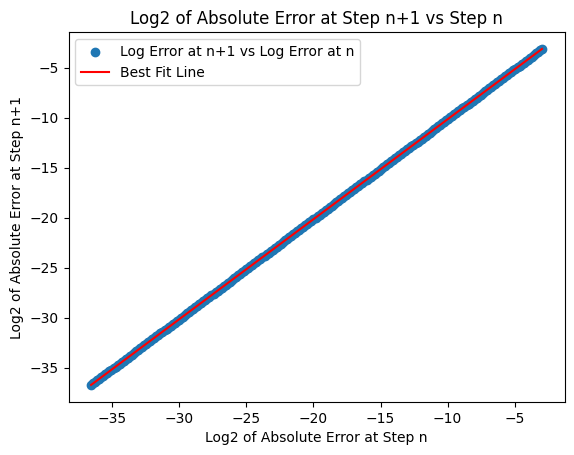

In [ ]:
def plot_error_progression(errors):
    # Calculating the log2 of the absolute error at step n and n+1
    log_errors = np.log2(errors)
    log_errors_n = log_errors[:-1]  # log errors at step n (excluding the last one)
    log_errors_n_plus_1 = log_errors[1:]  # log errors at step n+1 (excluding the first one)

    # Plotting log_errors_n+1 vs log_errors_n
    plt.scatter(log_errors_n, log_errors_n_plus_1, label='Log Error at n+1 vs Log Error at n')

    # Fitting a straight line to the data points
    slope, intercept = np.polyfit(log_errors_n, log_errors_n_plus_1, deg=1)
    print(slope,intercept)
    best_fit_line = slope * log_errors_n + intercept
    plt.plot(log_errors_n, best_fit_line, color='red', label='Best Fit Line')

    # Setting up the plot
    plt.xlabel('Log2 of Absolute Error at Step n')
    plt.ylabel('Log2 of Absolute Error at Step n+1')
    plt.title('Log2 of Absolute Error at Step n+1 vs Step n')
    plt.legend()
    plt.show()


def compute_slope_intercept(errors):
    errors = np.array(errors, dtype=float)

    # Remove zeros to avoid log issues
    errors = errors[errors > 0]

    # Form (e_n, e_{n+1}) pairs
    e_n = errors[:-1]
    e_np1 = errors[1:]

    # Take logs (base doesn't matter for slope)
    x = np.log2(e_n)
    y = np.log2(e_np1)

    # Compute slope and intercept
    slope, intercept = np.polyfit(x, y, 1)

    return slope, intercept


errors = [e for e in errors if e > 0]
print(compute_slope_intercept(errors))
plot_error_progression(errors)

# Multivariable Optimization

In [ ]:
f = lambda x, y: np.sin(x)*np.exp(-np.sqrt(x**2+y**2))

# Generating values for x and y
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Creating the plot
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y)])
fig.update_layout(width=800, height=800)

In [ ]:
def gradient_descent(df, x0, alpha, tol=1e-12, max_iter=10000):

    x = np.array(x0, dtype=float)

    for i in range(max_iter):

        grad = df(x)
        x_new = x - alpha * grad

        # stopping condition
        if np.linalg.norm(x_new - x) < tol:
            return x_new

        x = x_new

    return x

In [ ]:
def df(x):
    """
    Evaluate the gradient of f(x,y) = sin(x) exp(-sqrt(x**2+y**2))

    Parameter:
    x (NumPy array): Point at which to evaluate gradient.
                      x[0]=x, x[1]=y
    Returns:
    NumPy array: Gradient of f(x,y) at point x.
                 First element is df/dx, second element is df/dy.
    """

    # Calculate some values needed in the gradient
    s = np.sqrt(x[0]**2 + x[1]**2)
    e = np.exp(-s)

    # Need to handle case x=0,y=0 separately to avoid division by zero
    if s == 0:
        return np.array([1,0])

    gradient = np.zeros(2)
    gradient[0] = (np.cos(x[0]) - np.sin(x[0]) * x[0] / s) * e
    gradient[1] = - np.sin(x[0]) * x[1] / s * e

    return gradient

x0 = np.array([-1,1])

xmin = gradient_descent(df, x0, alpha=1, tol = 1e-6)

print(xmin)

[-7.85398163e-01  1.22132373e-06]


-------------------------------------------

In [ ]:
def gradient_descent(df, x0, alpha, tol=1e-6, max_iter=100000):
    x = np.array(x0, dtype=float)
    path = [x.copy()]

    for i in range(max_iter):
        x_new = x - alpha * df(x)
        path.append(x_new.copy())

        if np.linalg.norm(x_new - x) < tol:
            return path

        x = x_new

    return path

In [ ]:
f = lambda x: (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

df = lambda x: np.array([
    -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2),
    200 * (x[1] - x[0]**2)
])

In [ ]:
alpha = 0.001
path = gradient_descent(df, np.array([-1.0, 1.0]), alpha,
                        tol=1e-6, max_iter=100000)
print("final point:", path[-1])
print("iterations:", len(path) - 1)
print("final value:", f(path[-1]))

final point: [0.99888351 0.9977638 ]
iterations: 14749
final value: 1.2485424399189506e-06


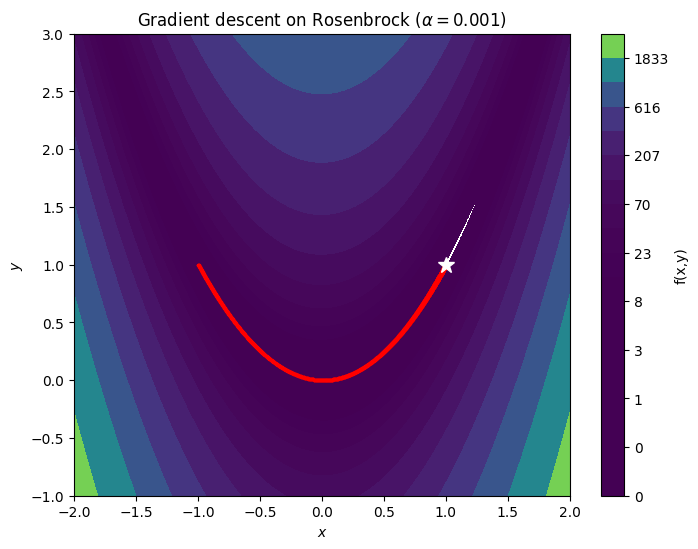

In [ ]:
x = np.linspace(-2, 2, 300)
y = np.linspace(-1, 3, 300)
X, Y = np.meshgrid(x, y)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=np.logspace(-1, 3.5, 20), cmap='viridis')
plt.colorbar(label='f(x,y)')

path = np.array(path)
plt.plot(path[:, 0], path[:, 1], 'r.-', markersize=3, linewidth=0.5)
plt.plot(1, 1, 'w*', markersize=12)

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Gradient descent on Rosenbrock ($\\alpha={alpha}$)')
plt.show()

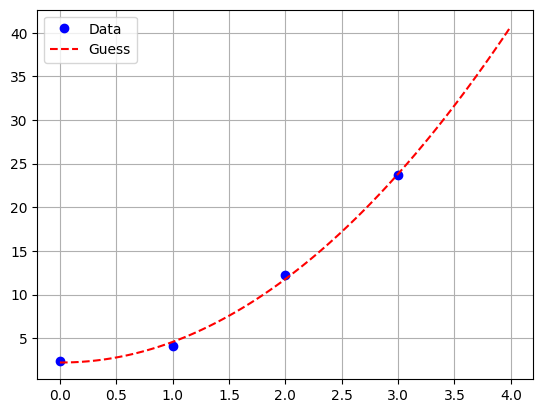

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
xdata = np.array([0, 1, 2, 3])
ydata = np.array([2.37, 4.14, 12.22, 23.68])
# make a plot of the data
plt.plot(xdata,ydata,'bo', label='Data')
# make a plot of the guessed function
a = 2.4225
b = -0.0665
c = 2.2235
x = np.linspace(0,4,100)
guess = a*x**2 + b*x + c
plt.plot(x,guess,'r--', label='Guess')
plt.grid()
plt.legend()

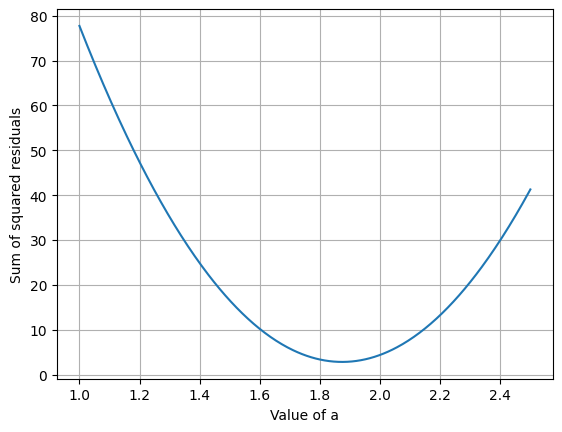

In [ ]:
xdata = np.array([0, 1, 2, 3])
ydata = np.array([2.37, 4.14, 12.22, 23.68])

b = 2
c = 0.75

A = np.linspace(1.0, 2.5, 400)
SumSqRes = []

for a in A:
    guess = a*xdata**2 + b*xdata + c
    residuals = guess - ydata
    SumSqRes.append(np.sum(residuals**2))

plt.plot(A, SumSqRes)
plt.grid()
plt.xlabel('Value of a')
plt.ylabel('Sum of squared residuals')
plt.show()